In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Tutorial 3

In [ ]:
df = pd.read_excel("NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx")

In [ ]:
df.head()

,NGAsubRSN,DatabaseRegion,NGAsubEQID,NGAsubSSN,Earthquake_Name,YEAR,MODY,HRMN,Earthquake_Magnitude,Hypocenter_Latitude_deg,...,T8pt500S,T9pt000S,T9pt500S,T10pt000S,T11pt000S,T12pt000S,T13pt000S,T14pt000S,T15pt000S,T20pt000S
0,1000001,Alaska,1000001,1000001,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000082,0.000095,0.000103,0.000125,0.000138,0.000109,0.000089,0.000064,0.000053,0.000061
1,1000002,Alaska,1000001,1000002,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000415,0.000395,0.000405,0.000390,0.000336,0.000332,0.000263,0.000215,0.000187,0.000119
2,1000003,Alaska,1000001,1000003,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000092,0.000083,0.000086,0.000082,0.000091,0.000078,0.000071,0.000066,0.000060,0.000055
3,1000004,Alaska,1000001,1000004,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000055,0.000053,0.000051,0.000055,0.000059,0.000058,0.000042,0.000035,0.000038,0.000028
4,1000005,Alaska,1000001,1000005,Aleutian_Isl-Alaska,2014,623,2053,7.96,51.6928,...,0.000129,0.000116,0.000128,0.000122,0.000130,0.000119,0.000096,0.000135,0.000162,0.000060


In [ ]:
df['Fault_Type']

0        0
1        0
2        0
3        0
4        0
        ..
71335    0
71336    0
71337    0
71338    0
71339    0
Name: Fault_Type, Length: 71340, dtype: int64

In [ ]:
# 1)M - Earthquake_Magnitude - we need to screen the data for M>=4 only
#2) Distance R: Rjb_km >=0 and Rjb_km <=500km only
#3) remove rows with parameters [M, R, Vs30, FM]<0
df_filtered = df[(df['Earthquake_Magnitude'] >= 4) & (df['Rjb_km'] >= 0) & (df['Rjb_km'] <= 500) &
                 (df['Vs30_Selected_for_Analysis_m_s'] > 0) & (df['Fault_Type'] > 0)]


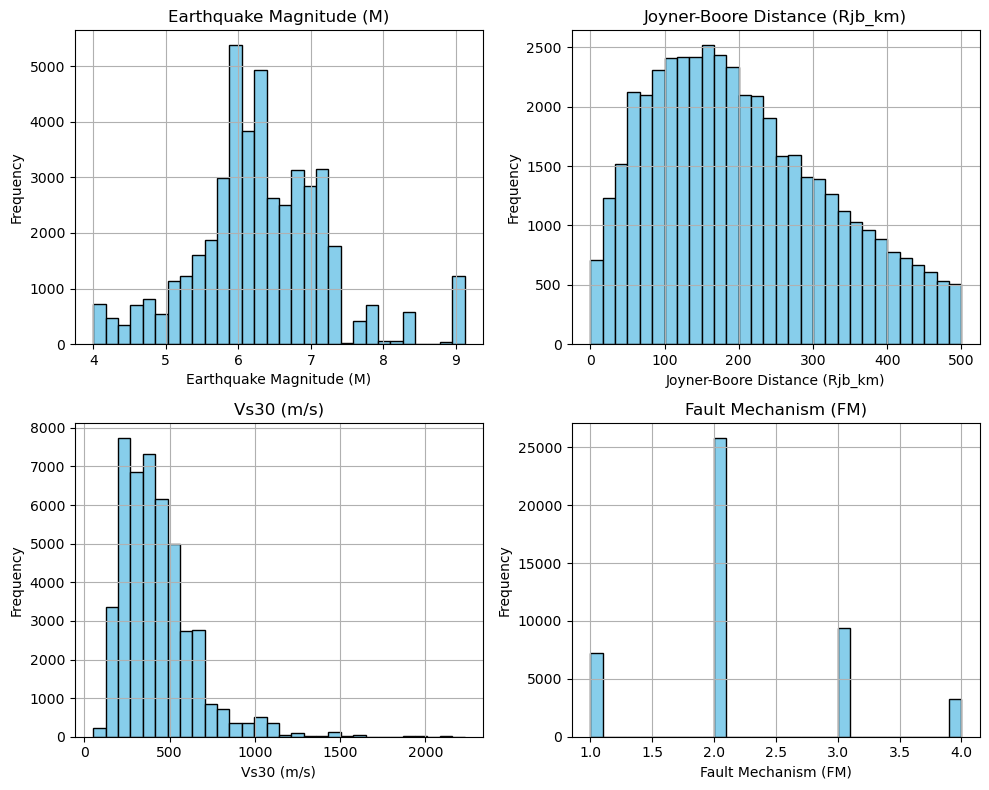

In [ ]:
#plots
#1) Histograms
# 1a) M - Earthquake_Magnitude
# 1b) R - Rjb_km
# 1c) Vs30 - Vs30_Selected_for_Analysis_m_s
# 1d) FM - Fault_Type
#lets plot in a 2*2 subplot using for loop
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
parameters = ['Earthquake_Magnitude', 'Rjb_km', 'Vs30_Selected_for_Analysis_m_s', 'Fault_Type']
titles = ['Earthquake Magnitude (M)', 'Joyner-Boore Distance (Rjb_km)', 'Vs30 (m/s)', 'Fault Mechanism (FM)']
for i, ax in enumerate(axs.flat):
    ax.hist(df_filtered[parameters[i]], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(titles[i])
    ax.set_xlabel(titles[i])
    ax.set_ylabel('Frequency')
    ax.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#2) Estimate : mean, median, standard deviation, skewness, kurtosis for M, R, Vs30, FM
stats = {}
parameters = ['Earthquake_Magnitude', 'Rjb_km', 'Vs30_Selected_for_Analysis_m_s', 'Fault_Type']
for param in parameters:
    stats[param] = {
        'Mean': df_filtered[param].mean(),
        'Median': df_filtered[param].median(),
        'Standard Deviation': df_filtered[param].std(),
        'Skewness': df_filtered[param].skew(),
        'Kurtosis': df_filtered[param].kurtosis()
    }
print(pd.DataFrame(stats))

                    Earthquake_Magnitude      Rjb_km  \
Mean                            6.312703  205.787532   
Median                          6.250000  187.855945   
Standard Deviation              0.940497  120.288405   
Skewness                        0.376554    0.482078   
Kurtosis                        1.114601   -0.605682   

                    Vs30_Selected_for_Analysis_m_s  Fault_Type  
Mean                                    425.512785    2.189075  
Median                                  386.100000    2.000000  
Standard Deviation                      212.708112    0.781950  
Skewness                                  1.731009    0.545335  
Kurtosis                                  5.587748    0.124444  


In [ ]:
df['PGA_g']

0        0.000051
1        0.002596
2        0.000138
3        0.000573
4        0.001979
           ...   
71335    0.009412
71336    0.016009
71337    0.004653
71338    0.004367
71339    0.007713
Name: PGA_g, Length: 71340, dtype: float64

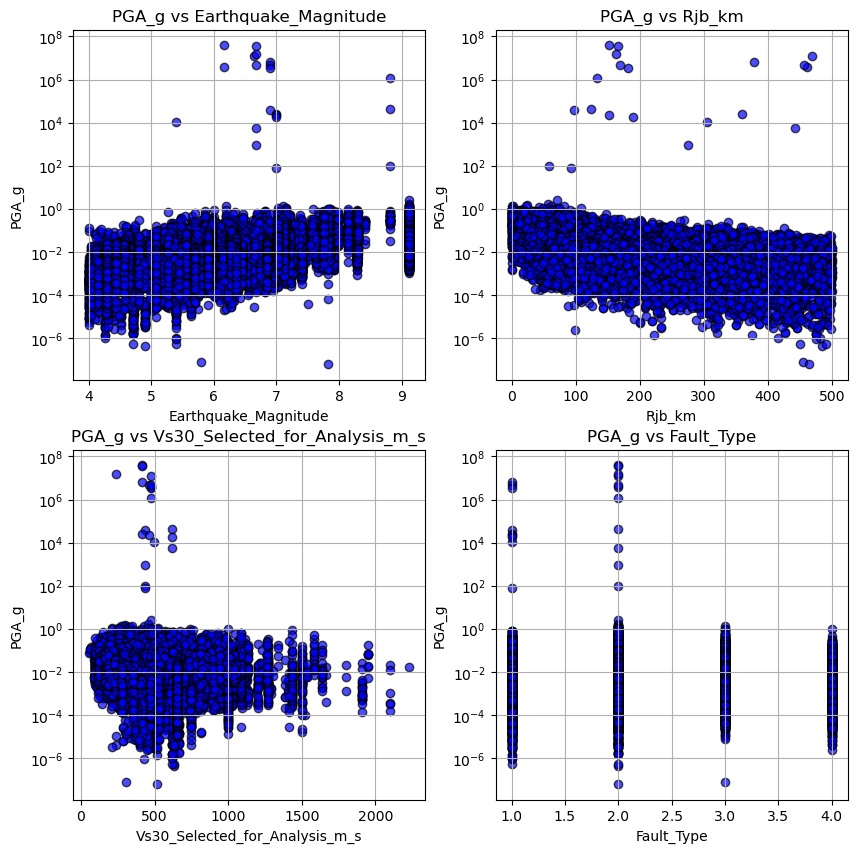

In [ ]:
#3) Graph : PGA_g vs M, PGA_g vs R, PGA_g vs Vs30, PGA_g vs FM with y axis on log scale
#lets plot in a 2*2 subplot using for loop
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
x_parameters = ['Earthquake_Magnitude', 'Rjb_km', 'Vs30_Selected_for_Analysis_m_s', 'Fault_Type']
y_parameter = 'PGA_g'
for i, ax in enumerate(axs.flat):
    ax.scatter(df_filtered[x_parameters[i]], df_filtered[y_parameter], color='blue', edgecolor='black', alpha=0.7)
    ax.set_title(f'PGA_g vs {x_parameters[i]}')
    ax.set_xlabel(x_parameters[i])
    ax.set_ylabel('PGA_g')
    ax.set_yscale('log')
    ax.grid(True)

Tutorial 2

In [ ]:
# 1)M - Earthquake_Magnitude - we need to screen the data for M>=4 only
#2) Distance R: Rjb_km >=0 and Rjb_km <=500km only
#3) remove rows with parameters [M, R, Vs30, FM]<0
df_filtered = df[(df['Earthquake_Magnitude'] >= 4) & (df['Rjb_km'] >= 0) & (df['Rjb_km'] <= 500) &
                 (df['Vs30_Selected_for_Analysis_m_s'] > 0) & (df['Fault_Type'] > 0)]

df_filtered.shape

(45675, 227)

In [ ]:
print( df.shape, df_filtered.shape)

(71340, 227) (45675, 227)


1. Plot response spectrum from flat file

In [ ]:
# we need plot response spectrum from flat file
psa_cols = [col for col in df_filtered.columns if col.startswith('T')]
print(psa_cols)
# PSA_till10S

['T0pt010S', 'T0pt020S', 'T0pt022S', 'T0pt025S', 'T0pt029S', 'T0pt030S', 'T0pt032S', 'T0pt035S', 'T0pt036S', 'T0pt040S', 'T0pt042S', 'T0pt044S', 'T0pt045S', 'T0pt046S', 'T0pt048S', 'T0pt050S', 'T0pt055S', 'T0pt060S', 'T0pt065S', 'T0pt067S', 'T0pt070S', 'T0pt075S', 'T0pt080S', 'T0pt085S', 'T0pt090S', 'T0pt095S', 'T0pt100S', 'T0pt110S', 'T0pt120S', 'T0pt130S', 'T0pt133S', 'T0pt140S', 'T0pt150S', 'T0pt160S', 'T0pt170S', 'T0pt180S', 'T0pt190S', 'T0pt200S', 'T0pt220S', 'T0pt240S', 'T0pt250S', 'T0pt260S', 'T0pt280S', 'T0pt290S', 'T0pt300S', 'T0pt320S', 'T0pt340S', 'T0pt350S', 'T0pt360S', 'T0pt380S', 'T0pt400S', 'T0pt420S', 'T0pt440S', 'T0pt450S', 'T0pt460S', 'T0pt480S', 'T0pt500S', 'T0pt550S', 'T0pt600S', 'T0pt650S', 'T0pt667S', 'T0pt700S', 'T0pt750S', 'T0pt800S', 'T0pt850S', 'T0pt900S', 'T0pt950S', 'T1pt000S', 'T1pt100S', 'T1pt200S', 'T1pt300S', 'T1pt400S', 'T1pt500S', 'T1pt600S', 'T1pt700S', 'T1pt800S', 'T1pt900S', 'T2pt000S', 'T2pt200S', 'T2pt400S', 'T2pt500S', 'T2pt600S', 'T2pt800S', 'T3

In [ ]:
df_filtered['NGAsubRSN']

60       1000061
73       1000074
85       1000086
108      1000109
121      1000122
          ...   
70872    7012036
70873    7012037
70874    7012038
70875    7012039
70876    7012040
Name: NGAsubRSN, Length: 45675, dtype: int64

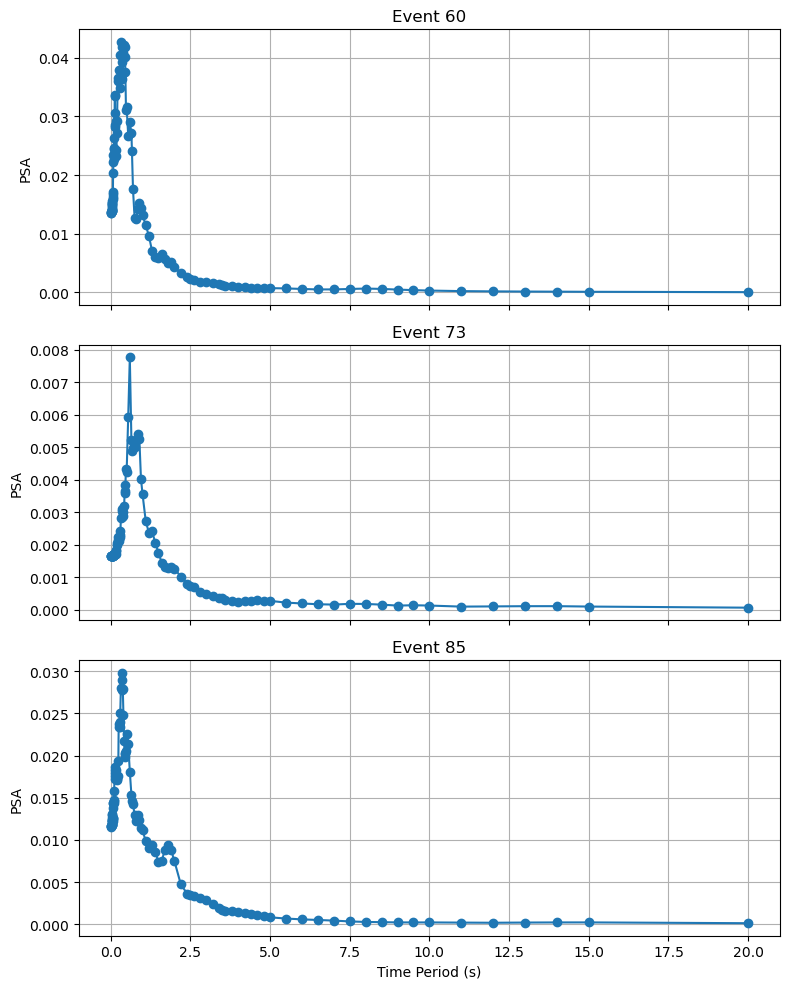

In [ ]:
# Extract time values
time = [float(col.replace("T", "").replace("S", "").replace("pt", "."))
        for col in psa_cols]

# Events (row indices)
event_indices = [60, 73, 85]

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)

for ax, idx in zip(axes, event_indices):
    # ax.set_yscale('log')
    # ax.set_xscale('log')
    psa_values = df_filtered.loc[idx, psa_cols].values
    ax.plot(time, psa_values, marker='o')
    ax.set_ylabel("PSA")
    ax.set_title(f"Event {idx }")
    ax.grid(True)

axes[-1].set_xlabel("Time Period (s)")

plt.tight_layout()
plt.show()


2. Scatter plots: magnitude vs PSA @ 0.1S, Rupture vs psa @0.1S, veolcity vs psa @0.1S

In [ ]:
# df_fitlered['Earthquake_Magnitude'] - rename to M
# df_filtered.rename(columns={'Earthquake_Magnitude': 'M'}, inplace=True)

C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_15640\1756709999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.rename(columns={'Earthquake_Magnitude': 'M'}, inplace=True)


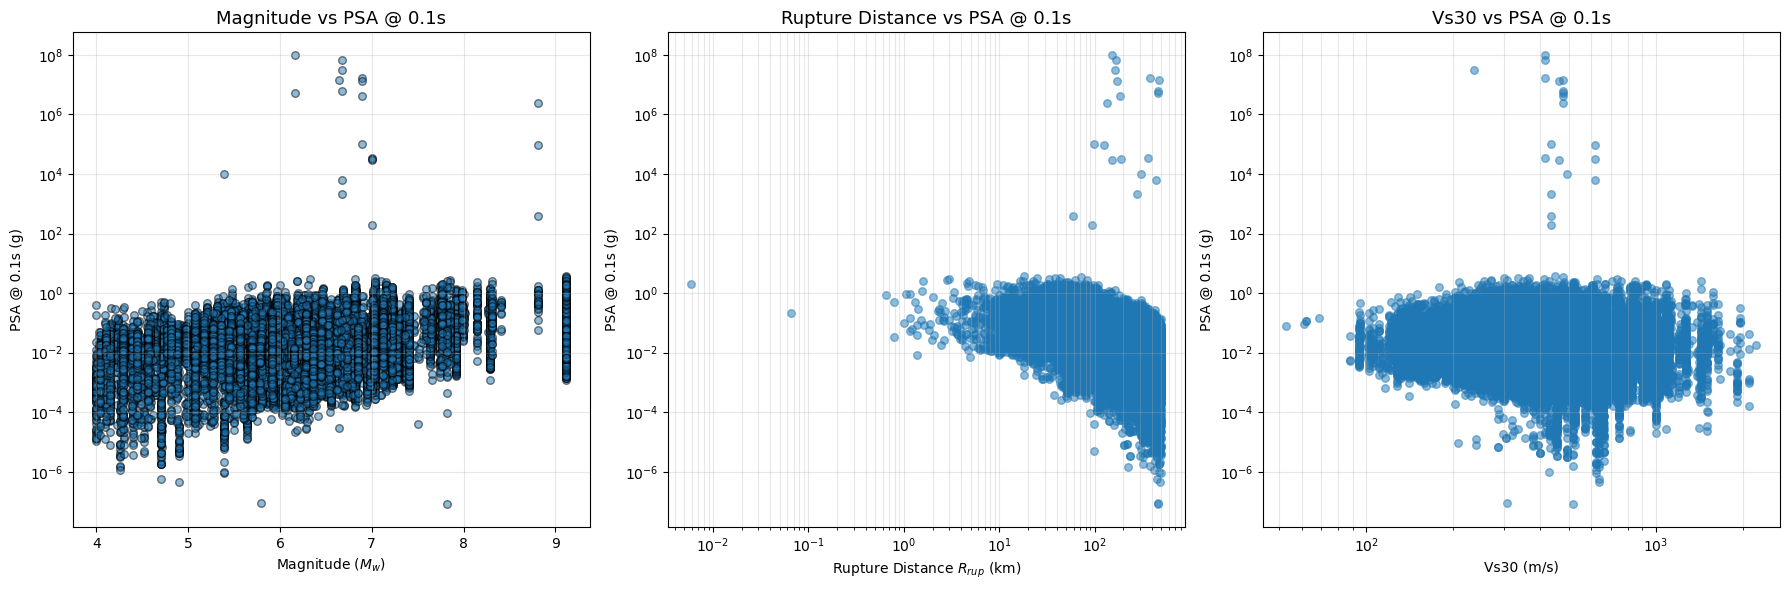

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# -------- Plot 1: Magnitude vs PSA --------
ax1.scatter(df_filtered['Earthquake_Magnitude'], df_filtered['T0pt100S'],
            alpha=0.5, edgecolors='k', s=30)

ax1.set_title('Magnitude vs PSA @ 0.1s', fontsize=13)
ax1.set_xlabel('Magnitude ($M_w$)')
ax1.set_ylabel('PSA @ 0.1s (g)')
ax1.set_yscale('log')
ax1.grid(True, which="both", alpha=0.3)

# -------- Plot 2: Rupture Distance vs PSA --------
ax2.scatter(df_filtered['Rjb_km'], df_filtered['T0pt100S'],
            alpha=0.5, s=30)

ax2.set_title('Rupture Distance vs PSA @ 0.1s', fontsize=13)
ax2.set_xlabel('Rupture Distance $R_{rup}$ (km)')
ax2.set_ylabel('PSA @ 0.1s (g)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, which="both", alpha=0.3)

# -------- Plot 3: Vs30 vs PSA --------
ax3.scatter(df_filtered['Vs30_Selected_for_Analysis_m_s'], df_filtered['T0pt100S'],
            alpha=0.5, s=30)

ax3.set_title('Vs30 vs PSA @ 0.1s', fontsize=13)
ax3.set_xlabel('Vs30 (m/s)')
ax3.set_ylabel('PSA @ 0.1s (g)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


3. Fit a linear regression for Input variables vs output variables
input varibles:
'Earthquake_Magnitude- M', 'Rjb_km', 'Vs30_Selected_for_Analysis_m_s', 'Fault_Type'
output varibles: PGA, PSA@0.1S

In [ ]:
df_filtered['Hypocenter_Depth_km']

60       37.20
73       37.20
85       46.00
108      46.00
121      46.00
         ...  
70872    16.62
70873    16.62
70874    16.62
70875    16.62
70876    16.62
Name: Hypocenter_Depth_km, Length: 45675, dtype: float64

In [ ]:
input_var = ['Earthquake_Magnitude', 'Rjb_km', 'Vs30_Selected_for_Analysis_m_s', 'Hypocenter_Depth_km']
# we will log transform Rjb_km and Vs30_Selected_for_Analysis_m_s
# log transform
df_filtered['log_Rjb_km'] = np.log(df_filtered['Rjb_km'])
df_filtered['log_Vs30'] = np.log(df_filtered['Vs30_Selected_for_Analysis_m_s'])
df_filtered['Hypocenter_Depth_km'] = np.log(df_filtered['Hypocenter_Depth_km'])
# df_filtered['log_Rjb_km']
#so now updated input_var
input_var = ['Earthquake_Magnitude', 'log_Rjb_km', 'log_Vs30', 'Hypocenter_Depth_km']


c:\Users\vishnu vardhan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_24832\461479036.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['log_Rjb_km'] = np.log(df_filtered['Rjb_km'])
C:\Users\vishnu vardhan\AppData\Local\Temp\ipykernel_24832\461479036.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['log_Vs30'] = n

In [ ]:
df_filtered.isna().sum().sum()

0

In [ ]:
# Check for inf or nan values
print("Checking for inf/nan in log-transformed columns:")
print(f"Inf values in log_Rjb_km: {np.isinf(df_filtered['log_Rjb_km']).sum()}")
print(f"Inf values in log_Vs30: {np.isinf(df_filtered['log_Vs30']).sum()}")
print(f"NaN values in log_Rjb_km: {df_filtered['log_Rjb_km'].isna().sum()}")
print(f"NaN values in log_Vs30: {df_filtered['log_Vs30'].isna().sum()}")

Checking for inf/nan in log-transformed columns:
Inf values in log_Rjb_km: 88
Inf values in log_Vs30: 0
NaN values in log_Rjb_km: 0
NaN values in log_Vs30: 0


In [ ]:


# Remove rows with inf or nan values
df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)
df_filtered = df_filtered.dropna(subset=['log_Rjb_km', 'log_Vs30', 'Fault_Type', 'T0pt100S'])
print(f"\nRows remaining after removing inf/nan: {len(df_filtered)}")



Rows remaining after removing inf/nan: 45587


In [ ]:
df_filtered.isna().sum().sum()

0

In [ ]:
df_filtered['Hypocenter_Depth_km']

60       3.616309
73       3.616309
85       3.828641
108      3.828641
121      3.828641
           ...   
70872    2.810607
70873    2.810607
70874    2.810607
70875    2.810607
70876    2.810607
Name: Hypocenter_Depth_km, Length: 45587, dtype: float64

In [ ]:
df_filtered['Hypocenter_Depth_km'].unique()

array([3.61630876, 3.8286414 , 2.94443898, 3.25809654, 3.82428409,
       3.75419892, 3.59456877, 2.81540872, 2.6461748 , 3.19458313,
       3.28840189, 2.89037176, 3.4657359 , 3.71113006, 2.50959926,
       2.7080502 , 3.74242022, 3.36037539, 2.07944154, 3.70622809,
       3.57234564, 3.47815842, 2.92852352, 3.55248683, 4.67656018,
       4.66908351, 3.46885603, 3.91601503, 4.78749174, 3.32862669,
       3.45315712, 3.6216707 , 4.53689135, 3.73050113, 2.60268969,
       2.83907846, 4.53367418, 3.60004824, 3.42426265, 3.44998755,
       3.45946629, 4.89933122, 3.02042489, 3.8329798 , 3.87120101,
       3.83729946, 3.61361697, 3.80888225, 2.93385687, 4.10758979,
       3.92395158, 2.77258872, 3.61899333, 3.51452607, 3.17805383,
       4.27805404, 3.39202881, 3.34990409, 3.74478709, 3.64283552,
       3.18635263, 3.19867312, 3.87743156, 3.41444261, 4.85670681,
       3.73528583, 3.38099467, 4.84339937, 3.55534806, 3.33220451,
       4.87672288, 4.07584109, 2.82731362, 5.31517448, 3.49650

In [ ]:
# 3. Fit a linear regression for Input variables vs output variables
# lets first import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Define input and output variables

X = df_filtered[input_var]
# our output variable is PSA at 0.1s
y = df_filtered['T0pt100S']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create a linear regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(X_train, y_train)
# Print the coefficients
coefficients = pd.DataFrame(model.coef_, input_var, columns=['Coefficient'])
print(coefficients)
# Make predictions on the test set
y_pred = model.predict(X_test)
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

                      Coefficient
Earthquake_Magnitude  -189.304600
log_Rjb_km             766.488656
log_Vs30              2391.905756
Hypocenter_Depth_km  -2806.680790
Mean Squared Error: 674501459944.5564
R^2 Score: -9.679208263269068e-05


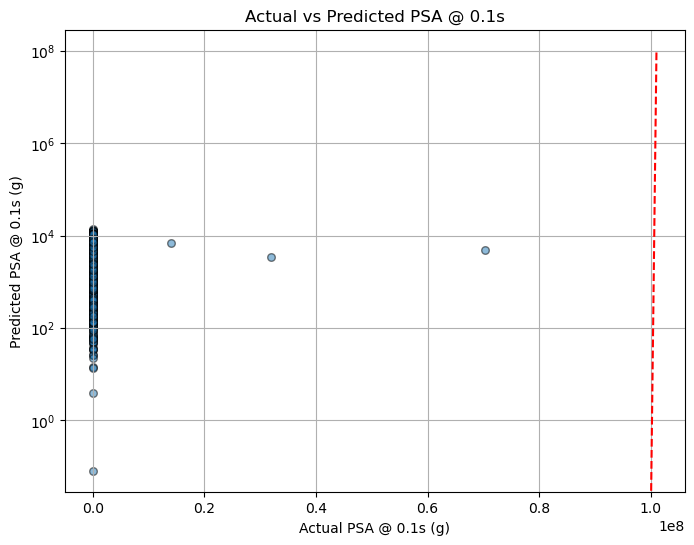

In [ ]:
#lets plot predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', s=30)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual PSA @ 0.1s (g)')
plt.ylabel('Predicted PSA @ 0.1s (g)')
plt.yscale('log')
plt.title('Actual vs Predicted PSA @ 0.1s')
plt.grid(True)
plt.show()
#set y scale to log



In [ ]:
#for the same input, but output variable as PGA_g
y_pga = df_filtered['PGA_g']
# Split the data into training and testing sets
X_train_pga, X_test_pga, y_train_pga, y_test_pga = train_test_split(X, y_pga, test_size=0.2, random_state=42)
# Create a linear regression model
model_pga = LinearRegression()
# Fit the model to the training data
model_pga.fit(X_train_pga, y_train_pga)
# Print the coefficients
coefficients_pga = pd.DataFrame(model_pga.coef_, input_var, columns=['Coefficient'])
print(coefficients_pga)
# Make predictions on the test set
y_pred_pga = model_pga.predict(X_test_pga)
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
mse_pga = mean_squared_error(y_test_pga, y_pred_pga)
r2_pga = r2_score(y_test_pga, y_pred_pga)
print(f"Mean Squared Error (PGA): {mse_pga}")
print(f"R^2 Score (PGA): {r2_pga}")

                     Coefficient
M                     -56.723563
log_Rjb_km            496.484656
log_Vs30             1098.278416
Hypocenter_Depth_km -1096.771024
Mean Squared Error (PGA): 181614641008.21973
R^2 Score (PGA): -0.0001317518785062255


4) Develop ANN for the same input and output variables

In [ ]:
# pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#lets first develop ann for input vs output PSA at 0.1s, code
import tensorflow as tf
from tensorflow import keras
# 4) Develop ANN for the same input and output variables
# Define the ANN model
model_ann = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(len(input_var),)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer for regression
])

ImportError: Traceback (most recent call last):
  File "c:\Users\vishnu vardhan\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [ ]:

# Compile the model
model_ann.compile(optimizer='adam', loss='mean_squared_error')
# Train the model
model_ann.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)
# Make predictions on the test set
y_pred_ann = model_ann.predict(X_test)
# Evaluate the model
mse_ann = mean_squared_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)
print(f"Mean Squared Error (ANN): {mse_ann}")
print(f"R^2 Score (ANN): {r2_ann}")

ImportError: Traceback (most recent call last):
  File "c:\Users\vishnu vardhan\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.